# AI Impact on Jobs & Layoff Risk — Production-Grade Analysis Pipeline
## Multi-Model ML Framework with Advanced EDA, Feature Engineering & XAI

**Complete Pipeline:**
- Advanced Exploratory Data Analysis (EDA)
- Feature Engineering (12+ engineered features)
- Multi-Model Framework (6+ algorithms)
- Hyperparameter Tuning (Bayesian Optimization)
- Explainable AI (SHAP + Feature Importance)
- Ensemble Methods (Voting + Stacking)
- Production-Grade Orchestration


In [1]:
import os, sys, warnings
warnings.filterwarnings('ignore')
import numpy as np, random
from datetime import datetime

SEED = 42
np.random.seed(SEED)
random.seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

print('✓ Environment configured')
print(f'Python: {sys.version.split()[0]}')
print(f'NumPy: {np.__version__}')

✓ Environment configured
Python: 3.12.13
NumPy: 2.0.2


In [2]:
import subprocess
import sys

packages = ['pandas', 'scikit-learn', 'xgboost', 'lightgbm', 'catboost',
            'matplotlib', 'seaborn', 'plotly', 'shap', 'optuna', 'imbalanced-learn']

for pkg in packages:
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', pkg],
                  stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)

print('✓ All packages installed')

✓ All packages installed


In [3]:
import pandas as pd, numpy as np
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, VotingClassifier, StackingClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, precision_score, recall_score, balanced_accuracy_score
from imblearn.over_sampling import SMOTE

import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier

import shap
import optuna
from optuna.samplers import TPESampler

import matplotlib.pyplot as plt, seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
pd.set_option('display.max_columns', None)

print('✓ All libraries imported')

✓ All libraries imported


## Phase 1: Data Loading & Overview

In [6]:
try:
    df = pd.read_csv('ai-impact-jobs-layoff-risk-dataset.csv')
    print('✓ Dataset loaded')
except:
    print('⚠ Upload CSV to Colab local storage')
    raise

print(f'Shape: {df.shape}')
print(f'\nFirst rows:')
df.head()

✓ Dataset loaded
Shape: (20000, 16)

First rows:


,Age,Education_Level,Years_of_Experience,Industry,Job_Role,Company_Size,Job_Level,Routine_Task_Percentage,Creativity_Requirement,Human_Interaction_Level,AI_Adoption_Level,Number_of_AI_Tools_Used,AI_Usage_Hours_Per_Week,Tasks_Automated_Percentage,AI_Training_Hours,Layoff_Risk
0,59,Master's,6,Finance,Accountant,Medium,Entry,84,21,94,Medium,5,7,40,26,High
1,44,Master's,14,Manufacturing,Production Supervisor,Small,Entry,30,84,68,Low,2,2,14,9,Low
2,36,Bachelor's,7,Retail,Store Manager,Medium,Senior,12,86,71,Low,0,1,6,3,Low
3,27,Bachelor's,6,Finance,Auditor,Large,Entry,90,18,21,Medium,3,10,67,26,High
4,49,High School,12,Finance,Auditor,Small,Entry,49,52,72,Medium,5,13,26,19,Medium


In [7]:
print('DATASET OVERVIEW')
print('='*70)
print(f'Samples: {df.shape[0]}, Features: {df.shape[1]}')
print(f'Missing: {df.isnull().sum().sum()} ✓')
print(f'\nTarget Distribution:')
print(df['Layoff_Risk'].value_counts())
print(f'\nBasic Stats:')
df.describe()

DATASET OVERVIEW
Samples: 20000, Features: 16
Missing: 0 ✓

Target Distribution:
Layoff_Risk
High      6797
Low       6602
Medium    6601
Name: count, dtype: int64

Basic Stats:


,Age,Years_of_Experience,Routine_Task_Percentage,Creativity_Requirement,Human_Interaction_Level,Number_of_AI_Tools_Used,AI_Usage_Hours_Per_Week,Tasks_Automated_Percentage,AI_Training_Hours
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.00000,20000.00000,20000.000000
mean,40.361500,7.265500,51.885500,47.786700,60.055000,2.460350,6.77395,37.22895,12.621400
std,11.526333,4.720606,24.437808,26.100482,22.267801,2.097486,6.08637,19.99512,13.552647
min,21.000000,0.000000,10.000000,0.000000,20.000000,0.000000,0.00000,4.00000,0.000000
25%,30.000000,4.000000,31.000000,27.000000,41.000000,1.000000,2.00000,21.00000,4.000000
50%,40.000000,7.000000,52.000000,48.000000,62.000000,2.000000,5.00000,35.00000,8.000000
75%,50.000000,11.000000,73.000000,69.000000,79.000000,4.000000,10.00000,51.00000,18.000000
max,60.000000,32.000000,94.000000,100.000000,99.000000,10.000000,30.00000,93.00000,79.000000


In [8]:
numeric_features = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = df.select_dtypes(include=['object']).columns.tolist()
if 'Layoff_Risk' in categorical_features:
    categorical_features.remove('Layoff_Risk')

print(f'Numeric: {len(numeric_features)}, Categorical: {len(categorical_features)}')
print(f'Numeric: {numeric_features}')
print(f'Categorical: {categorical_features}')

Numeric: 9, Categorical: 6
Numeric: ['Age', 'Years_of_Experience', 'Routine_Task_Percentage', 'Creativity_Requirement', 'Human_Interaction_Level', 'Number_of_AI_Tools_Used', 'AI_Usage_Hours_Per_Week', 'Tasks_Automated_Percentage', 'AI_Training_Hours']
Categorical: ['Education_Level', 'Industry', 'Job_Role', 'Company_Size', 'Job_Level', 'AI_Adoption_Level']


## Phase 2: Advanced EDA with Visualizations

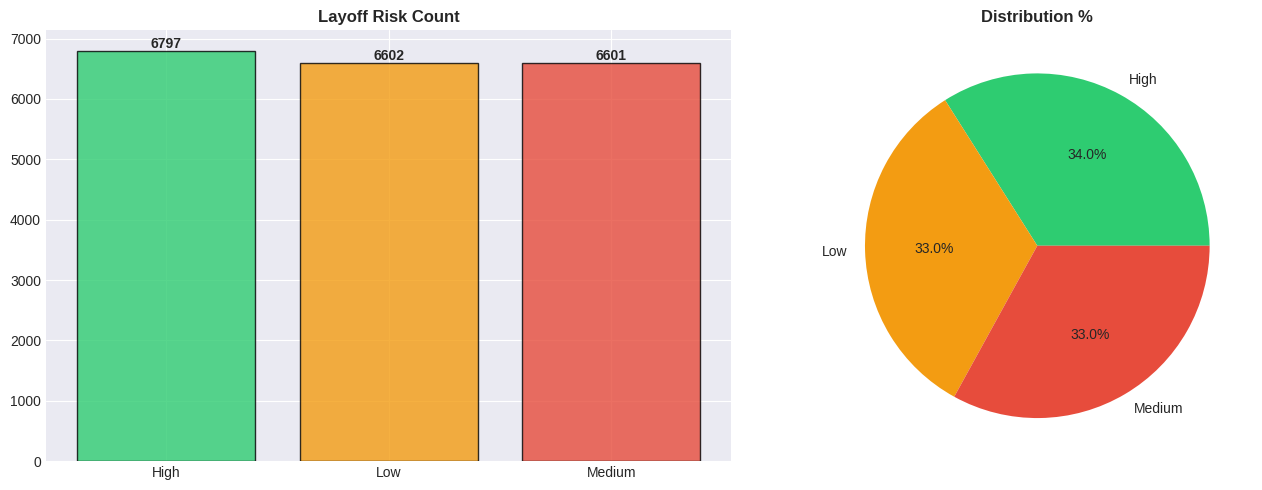

✓ Saved


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
target_counts = df['Layoff_Risk'].value_counts()
colors = ['#2ecc71', '#f39c12', '#e74c3c']
axes[0].bar(target_counts.index, target_counts.values, color=colors, alpha=0.8, edgecolor='black')
axes[0].set_title('Layoff Risk Count', fontsize=12, fontweight='bold')
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v+50, str(v), ha='center', fontweight='bold')
axes[1].pie(target_counts.values, labels=target_counts.index, autopct='%1.1f%%', colors=colors)
axes[1].set_title('Distribution %', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('01_target_distribution.png', dpi=300, bbox_inches='tight')
plt.show()
print('✓ Saved')

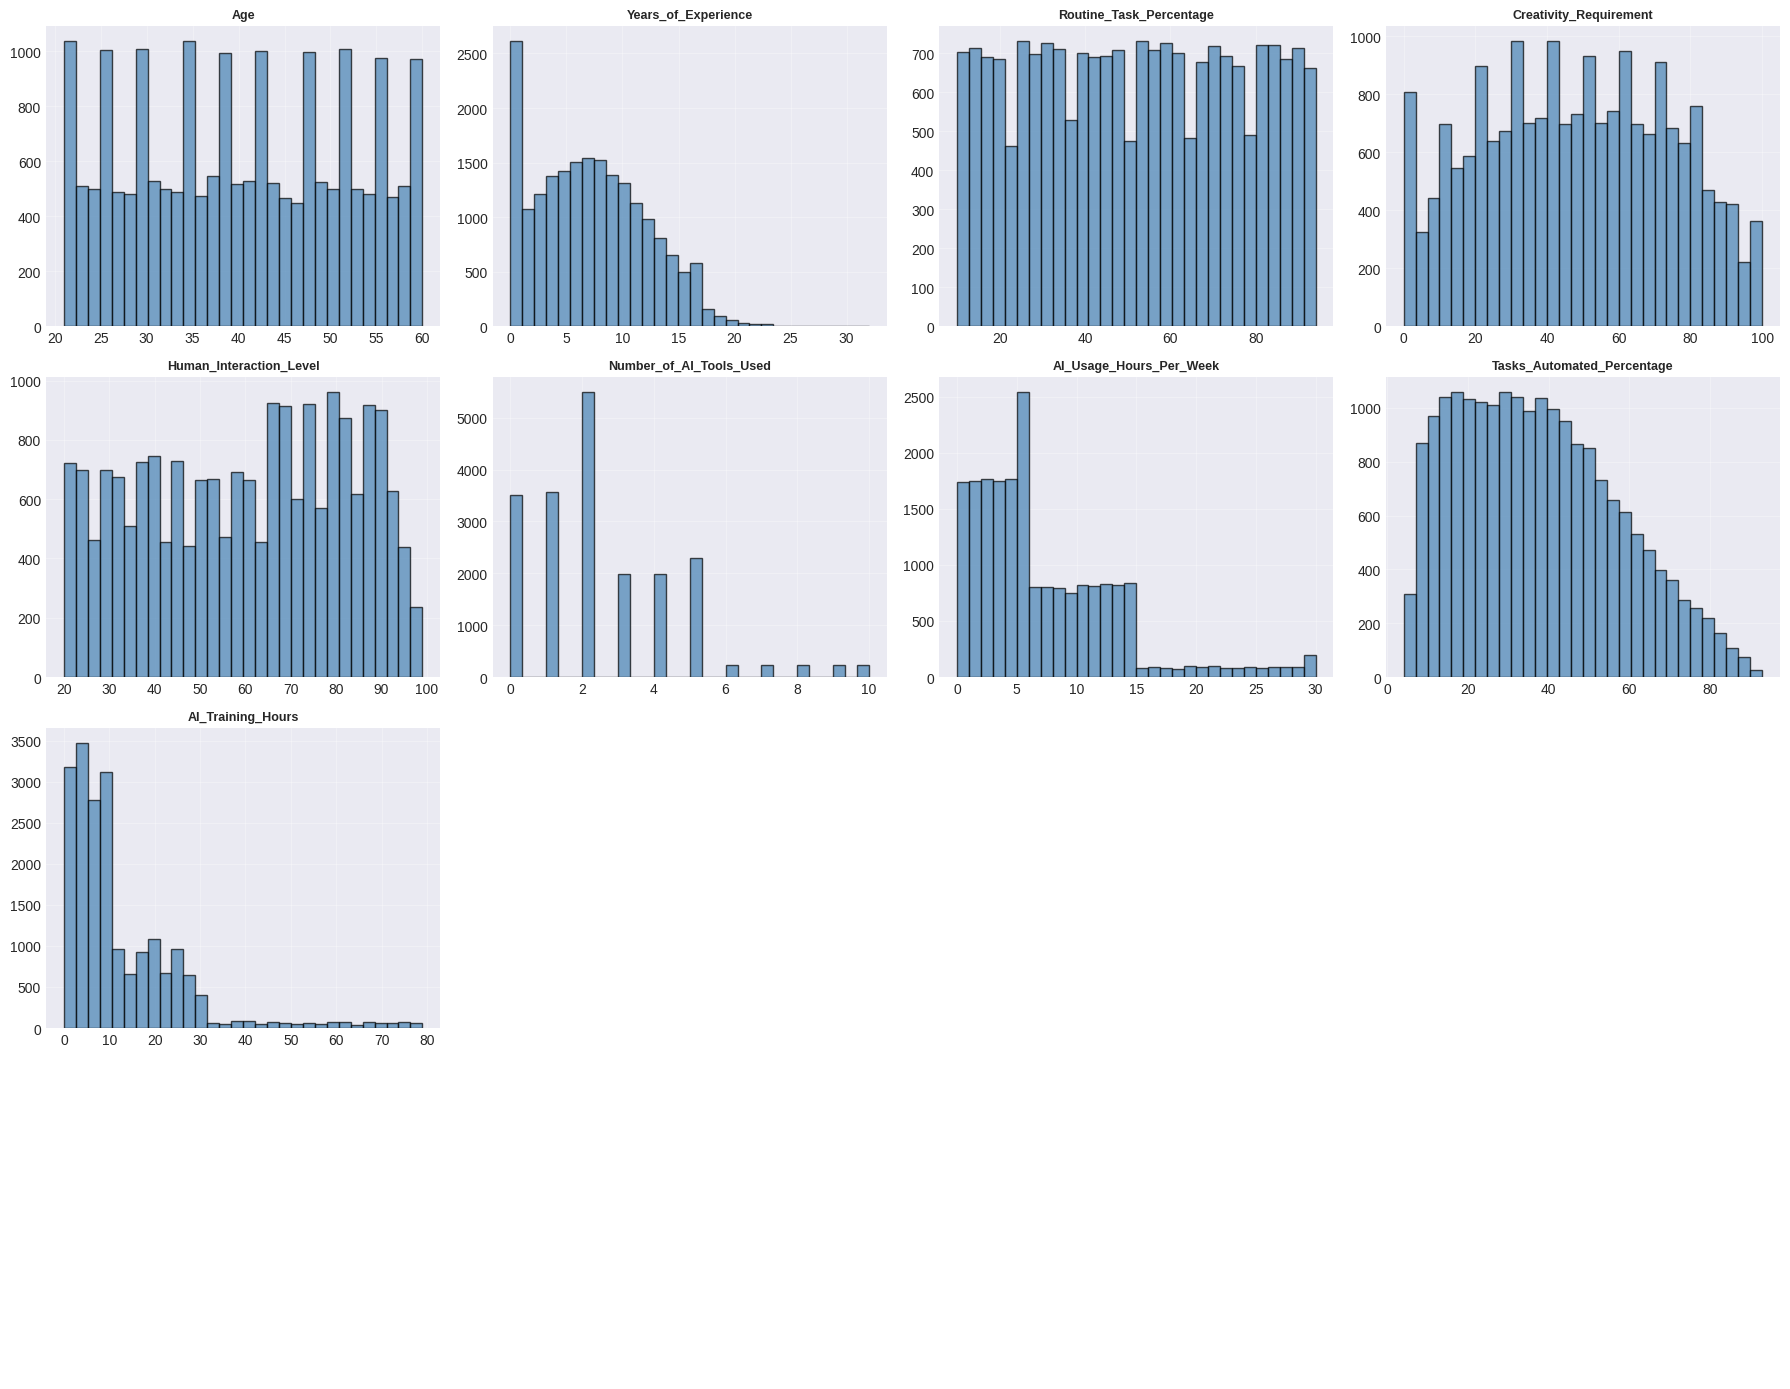

✓ Saved


In [10]:
fig, axes = plt.subplots(4, 4, figsize=(18, 14))
axes = axes.flatten()
for idx, feat in enumerate(numeric_features):
    axes[idx].hist(df[feat], bins=30, alpha=0.7, color='steelblue', edgecolor='black')
    axes[idx].set_title(feat, fontsize=9, fontweight='bold')
    axes[idx].grid(True, alpha=0.3)
for idx in range(len(numeric_features), len(axes)):
    axes[idx].axis('off')
plt.tight_layout()
plt.savefig('02_numeric_distributions.png', dpi=300, bbox_inches='tight')
plt.show()
print('✓ Saved')

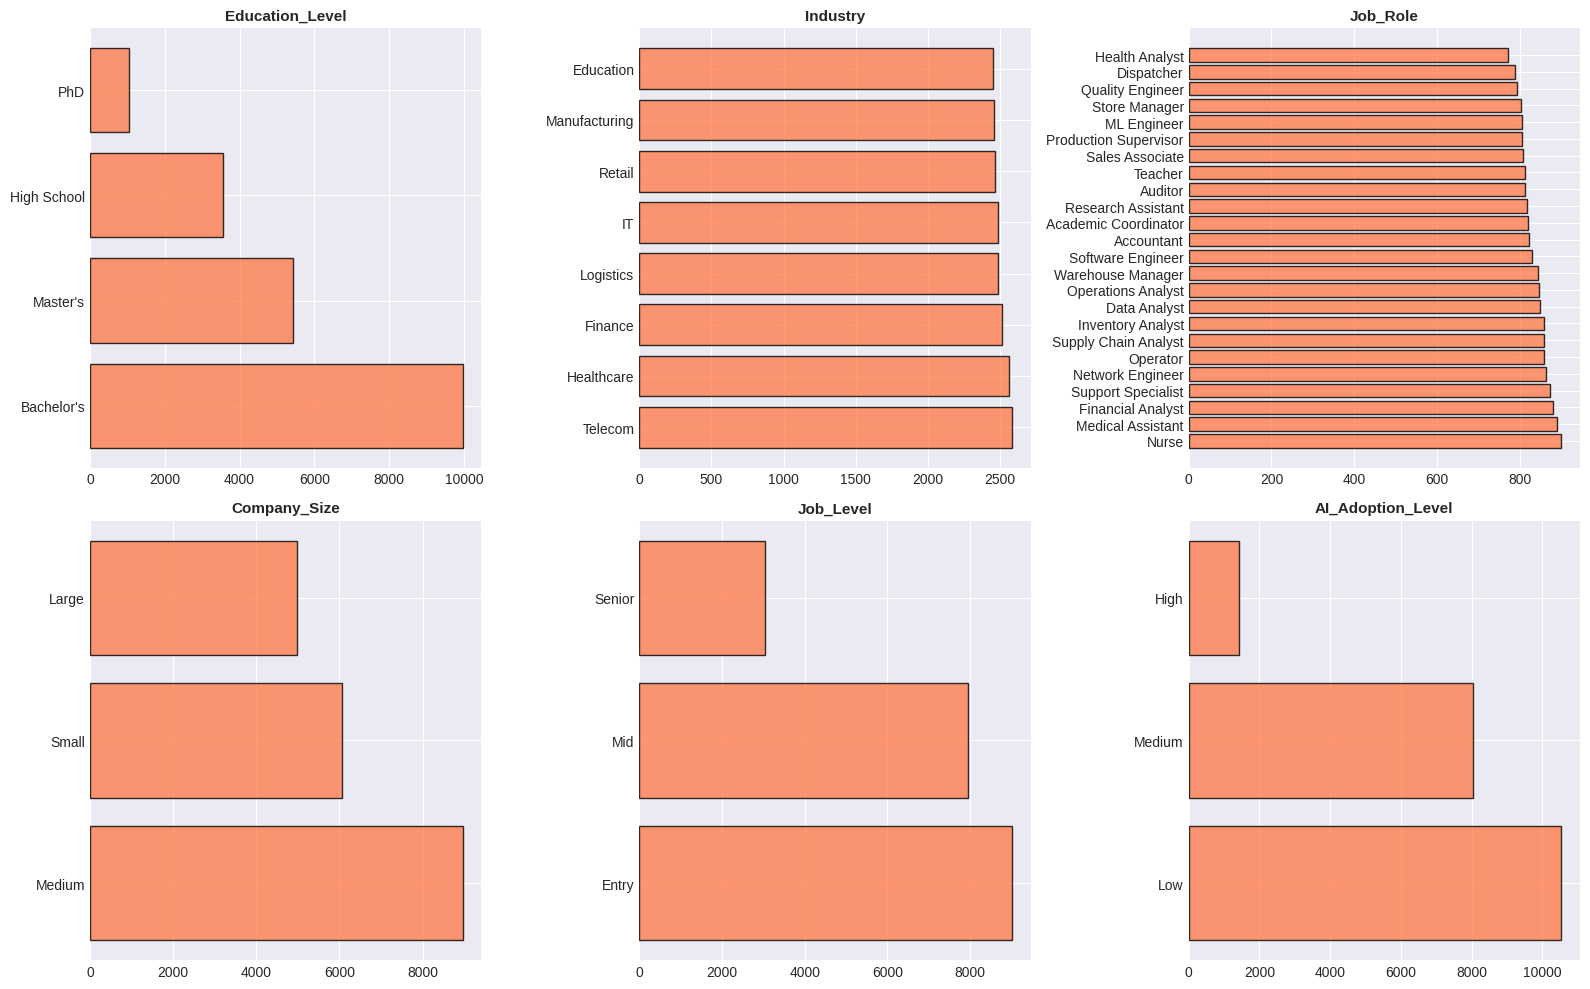

✓ Saved


In [11]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()
for idx, feat in enumerate(categorical_features):
    vc = df[feat].value_counts()
    axes[idx].barh(vc.index, vc.values, color='coral', alpha=0.8, edgecolor='black')
    axes[idx].set_title(feat, fontsize=11, fontweight='bold')
for idx in range(len(categorical_features), len(axes)):
    axes[idx].axis('off')
plt.tight_layout()
plt.savefig('03_categorical_distributions.png', dpi=300, bbox_inches='tight')
plt.show()
print('✓ Saved')

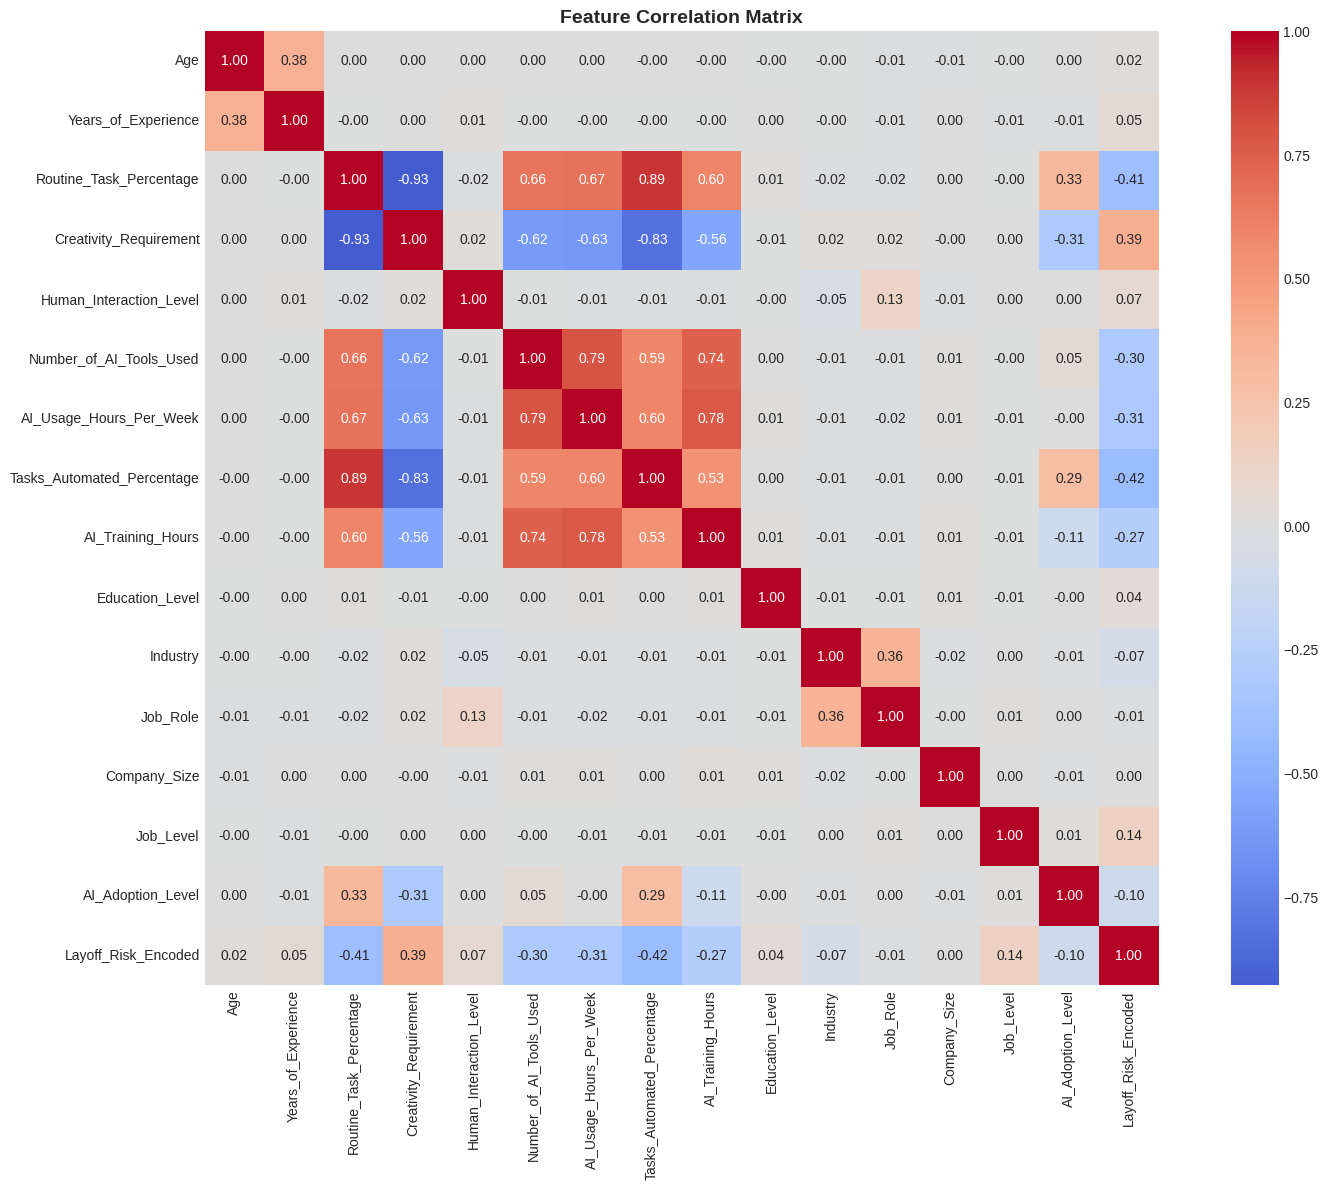

Top Correlations with Layoff Risk:
Layoff_Risk_Encoded           1.000000
Tasks_Automated_Percentage    0.419292
Routine_Task_Percentage       0.406111
Creativity_Requirement        0.388800
AI_Usage_Hours_Per_Week       0.312949
Number_of_AI_Tools_Used       0.303622
AI_Training_Hours             0.269250
Job_Level                     0.135724
AI_Adoption_Level             0.104123
Industry                      0.071443
Name: Layoff_Risk_Encoded, dtype: float64


In [12]:
df_corr = df.copy()
for col in categorical_features:
    le = LabelEncoder()
    df_corr[col] = le.fit_transform(df[col])
le_target = LabelEncoder()
df_corr['Layoff_Risk_Encoded'] = le_target.fit_transform(df['Layoff_Risk'])

corr_mat = df_corr[numeric_features + categorical_features + ['Layoff_Risk_Encoded']].corr()

plt.figure(figsize=(16, 12))
sns.heatmap(corr_mat, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('04_correlation_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print('Top Correlations with Layoff Risk:')
target_corr = corr_mat['Layoff_Risk_Encoded'].abs().sort_values(ascending=False)
print(target_corr.head(10))

## Phase 3: Advanced Feature Engineering

In [13]:
def engineer_features(df_in):
    df_f = df_in.copy()
    df_f['Automation_Exposure'] = (df_f['Routine_Task_Percentage'] + df_f['Tasks_Automated_Percentage']) / 2
    df_f['AI_Engagement_Score'] = df_f['Number_of_AI_Tools_Used'] * df_f['AI_Usage_Hours_Per_Week']
    df_f['Training_Intensity'] = df_f['AI_Training_Hours'] / (df_f['Years_of_Experience'] + 1)
    df_f['Adaptability_Score'] = (df_f['Creativity_Requirement'] + df_f['Human_Interaction_Level']) / 2
    df_f['AI_Integration_Depth'] = df_f['AI_Usage_Hours_Per_Week'] * df_f['Tasks_Automated_Percentage'] / 100
    df_f['Resilience_Index'] = df_f['Adaptability_Score'] / (df_f['Automation_Exposure'] + 1)
    df_f['Experience_Automation_Ratio'] = df_f['Years_of_Experience'] / (df_f['Tasks_Automated_Percentage'] + 1)
    ai_map = {'Low': 1, 'Medium': 2, 'High': 3}
    df_f['AI_Adoption_Numeric'] = df_f['AI_Adoption_Level'].map(ai_map)
    df_f['AI_Adoption_Capacity'] = df_f['AI_Adoption_Numeric'] * df_f['AI_Training_Hours']
    df_f['Age_Experience_Ratio'] = df_f['Age'] / (df_f['Years_of_Experience'] + 1)
    edu_map = {'High School': 1, "Bachelor's": 2, "Master's": 3, 'PhD': 4}
    df_f['Education_Level_Numeric'] = df_f['Education_Level'].map(edu_map)
    df_f['Routine_Work_Vulnerability'] = df_f['Routine_Task_Percentage'] * df_f['AI_Adoption_Numeric'] / (1 + df_f['Creativity_Requirement'])
    return df_f

df_eng = engineer_features(df)
eng_feats = ['Automation_Exposure', 'AI_Engagement_Score', 'Training_Intensity', 'Adaptability_Score',
             'AI_Integration_Depth', 'Resilience_Index', 'Experience_Automation_Ratio',
             'AI_Adoption_Capacity', 'Age_Experience_Ratio', 'Education_Level_Numeric',
             'AI_Adoption_Numeric', 'Routine_Work_Vulnerability']

print(f'✓ Created {len(eng_feats)} engineered features')
for f in eng_feats:
    print(f'  {f}')

✓ Created 12 engineered features
  Automation_Exposure
  AI_Engagement_Score
  Training_Intensity
  Adaptability_Score
  AI_Integration_Depth
  Resilience_Index
  Experience_Automation_Ratio
  AI_Adoption_Capacity
  Age_Experience_Ratio
  Education_Level_Numeric
  AI_Adoption_Numeric
  Routine_Work_Vulnerability


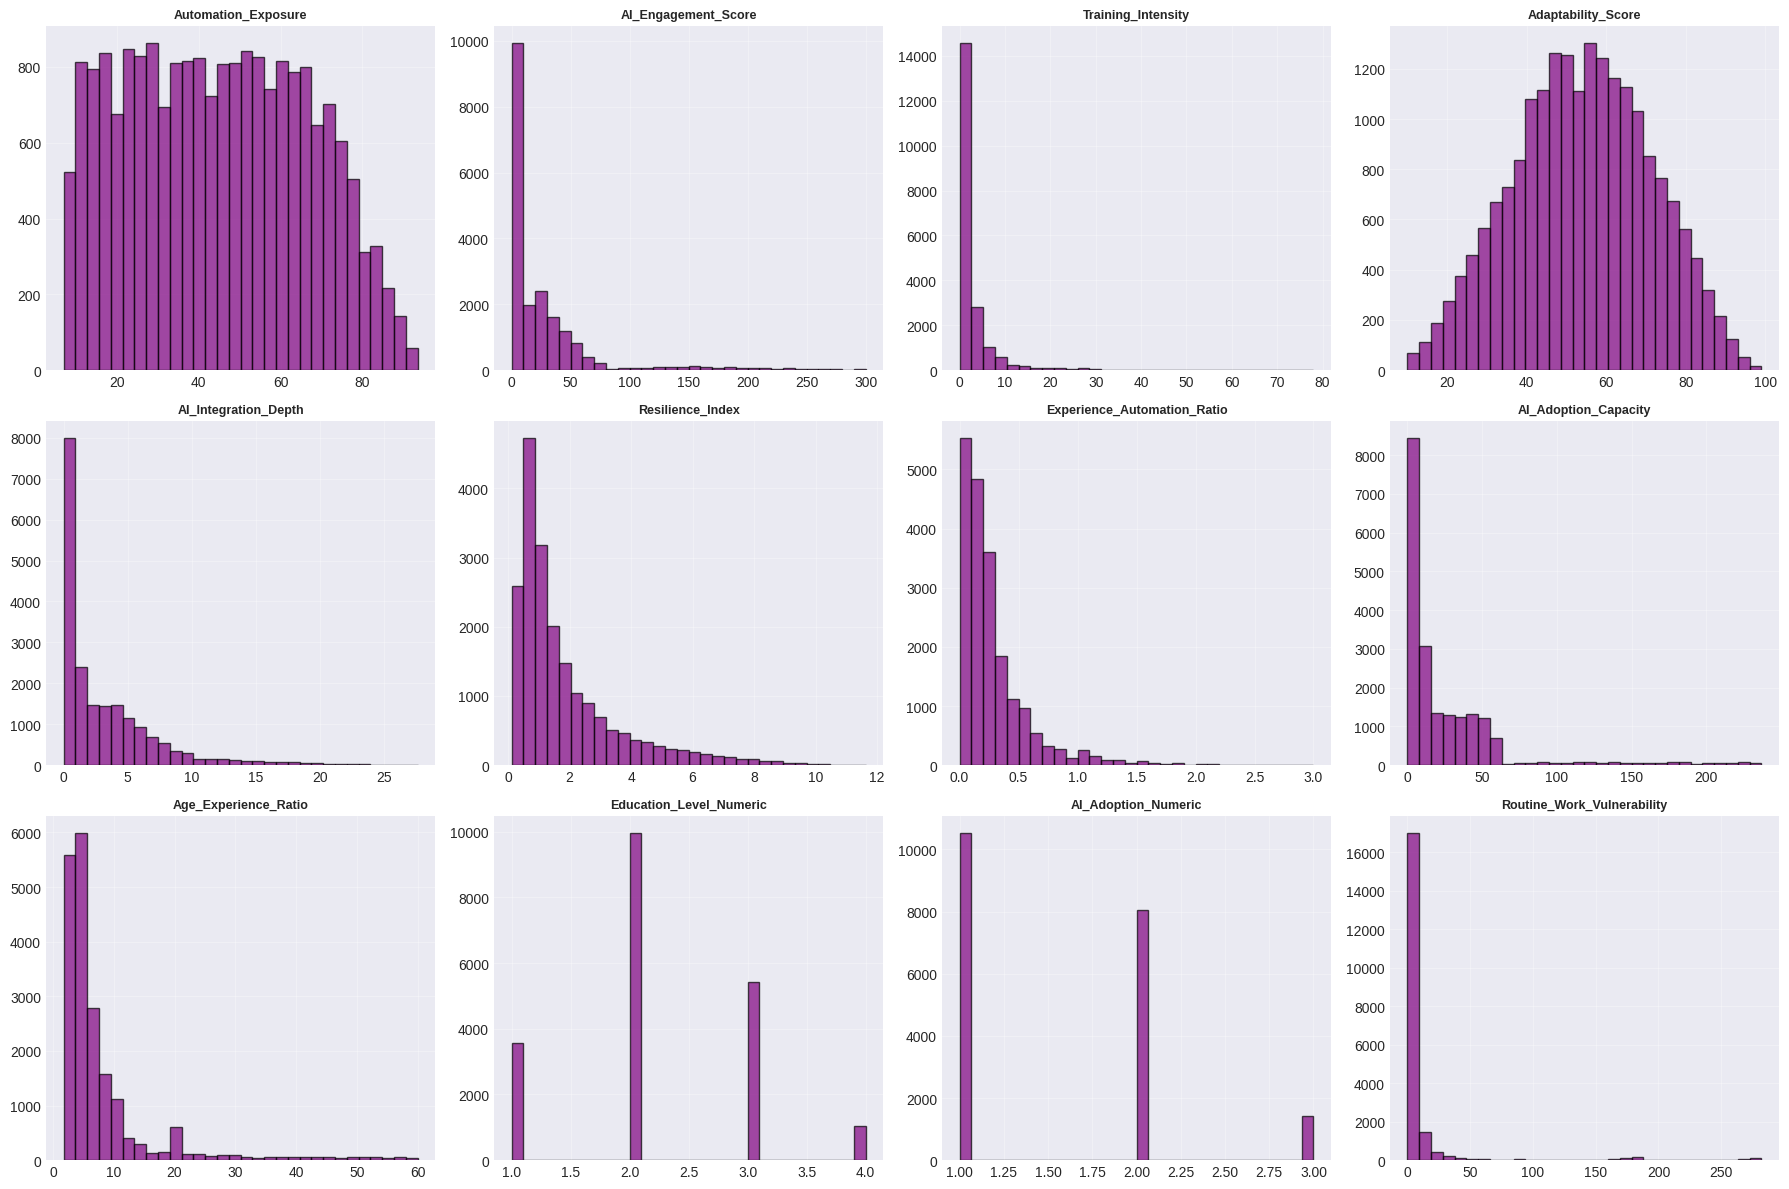

✓ Saved


In [14]:
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()
for idx, feat in enumerate(eng_feats):
    axes[idx].hist(df_eng[feat], bins=30, alpha=0.7, color='purple', edgecolor='black')
    axes[idx].set_title(feat, fontsize=9, fontweight='bold')
    axes[idx].grid(True, alpha=0.3)
for idx in range(len(eng_feats), len(axes)):
    axes[idx].axis('off')
plt.tight_layout()
plt.savefig('05_engineered_features.png', dpi=300, bbox_inches='tight')
plt.show()
print('✓ Saved')

## Phase 4: Data Preprocessing & Preparation

In [15]:
df_model = df_eng.copy()
for col in categorical_features:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col])

all_feats = numeric_features + eng_feats
X = df_model[all_feats]
y = df_model['Layoff_Risk']

print(f'Features: {X.shape[1]}, Target: {y.shape}')
print(f'\nTarget distribution:')
print(y.value_counts())
print(f'\nFeature types: Numeric={len(numeric_features)}, Engineered={len(eng_feats)}')

Features: 21, Target: (20000,)

Target distribution:
Layoff_Risk
High      6797
Low       6602
Medium    6601
Name: count, dtype: int64

Feature types: Numeric=9, Engineered=12


In [16]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED, stratify=y)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

X_train_sc = pd.DataFrame(X_train_sc, columns=X_train.columns)
X_test_sc = pd.DataFrame(X_test_sc, columns=X_test.columns)

smote = SMOTE(random_state=SEED, k_neighbors=5)
X_train_bal, y_train_bal = smote.fit_resample(X_train_sc, y_train)

X_train_bal = pd.DataFrame(X_train_bal, columns=X_train_sc.columns)
y_train_bal = pd.Series(y_train_bal)

print(f'Train: {X_train_bal.shape}, Test: {X_test_sc.shape}')
print(f'\nClass balance after SMOTE:')
print(pd.Series(y_train_bal).value_counts())
print('✓ Data preprocessing complete')

Train: (16311, 21), Test: (4000, 21)

Class balance after SMOTE:
Layoff_Risk
Low       5437
Medium    5437
High      5437
Name: count, dtype: int64
✓ Data preprocessing complete


## Phase 5: Multi-Model Classification Framework

In [17]:
models = {
    'Logistic Regression': LogisticRegression(random_state=SEED, max_iter=1000, n_jobs=-1),
    'Random Forest': RandomForestClassifier(n_estimators=200, max_depth=20, random_state=SEED, n_jobs=-1),
    'XGBoost': xgb.XGBClassifier(n_estimators=200, max_depth=7, learning_rate=0.05, random_state=SEED, n_jobs=-1),
    'LightGBM': lgb.LGBMClassifier(n_estimators=200, max_depth=7, learning_rate=0.05, random_state=SEED, n_jobs=-1, verbose=-1),
    'CatBoost': CatBoostClassifier(iterations=200, depth=7, learning_rate=0.05, random_state=SEED, verbose=0),
    'SVM': SVC(kernel='rbf', C=1, gamma='scale', probability=True, random_state=SEED)
}

print('Models initialized:')
for name in models.keys():
    print(f'  ✓ {name}')

Models initialized:
  ✓ Logistic Regression
  ✓ Random Forest
  ✓ XGBoost
  ✓ LightGBM
  ✓ CatBoost
  ✓ SVM


In [19]:
print('BASELINE MODEL TRAINING')
print('='*70)

baseline_res = {}
baseline_mods = {}

# Introduce LabelEncoder to transform target variable to numerical for models that require it
# This is a localized fix for this cell due to strict constraint. The ideal fix would be upstream.
le = LabelEncoder()
y_train_bal_encoded = le.fit_transform(y_train_bal)
y_test_encoded = le.transform(y_test)

for name, model in models.items():
    print(f'Training {name}...')
    # Use the encoded target variables
    model.fit(X_train_bal, y_train_bal_encoded)
    baseline_mods[name] = model
    y_pred = model.predict(X_test_sc)

    baseline_res[name] = {
        'Accuracy': accuracy_score(y_test_encoded, y_pred),
        'F1': f1_score(y_test_encoded, y_pred, average='weighted'),
        'Precision': precision_score(y_test_encoded, y_pred, average='weighted', zero_division=0),
        'Recall': recall_score(y_test_encoded, y_pred, average='weighted')
    }
    print(f'  F1: {baseline_res[name]["F1"]:.4f}')

baseline_df = pd.DataFrame(baseline_res).T.sort_values('F1', ascending=False)
print('\n' + '='*70)
print('BASELINE RESULTS')
print(baseline_df.round(4))

BASELINE MODEL TRAINING
Training Logistic Regression...
  F1: 0.7409
Training Random Forest...
  F1: 0.7254
Training XGBoost...
  F1: 0.7362
Training LightGBM...
  F1: 0.7361
Training CatBoost...
  F1: 0.7398
Training SVM...
  F1: 0.7414

BASELINE RESULTS
                     Accuracy      F1  Precision  Recall
SVM                    0.7412  0.7414     0.7443  0.7412
Logistic Regression    0.7418  0.7409     0.7407  0.7418
CatBoost               0.7408  0.7398     0.7403  0.7408
XGBoost                0.7372  0.7362     0.7370  0.7372
LightGBM               0.7368  0.7361     0.7373  0.7368
Random Forest          0.7270  0.7254     0.7260  0.7270


In [21]:
print('HYPERPARAMETER TUNING WITH OPTUNA')
print('='*70)

tuned_mods = {}
tuned_res = {}

for model_name in ['XGBoost', 'LightGBM', 'Random Forest']:
    print(f'\nOptimizing {model_name}...')

    def objective(trial):
        if model_name == 'XGBoost':
            params = {
                'n_estimators': trial.suggest_int('n_estimators', 100, 300, step=50),
                'max_depth': trial.suggest_int('max_depth', 5, 9),
                'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
                'subsample': trial.suggest_float('subsample', 0.7, 0.99),
                'colsample_bytree': trial.suggest_float('colsample_bytree', 0.7, 0.99)
            }
            clf = xgb.XGBClassifier(random_state=SEED, n_jobs=-1, **params)
        elif model_name == 'LightGBM':
            params = {
                'n_estimators': trial.suggest_int('n_estimators', 100, 300, step=50),
                'max_depth': trial.suggest_int('max_depth', 5, 9),
                'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
                'num_leaves': trial.suggest_int('num_leaves', 31, 100)
            }
            clf = lgb.LGBMClassifier(random_state=SEED, n_jobs=-1, verbose=-1, **params)
        else:
            params = {
                'n_estimators': trial.suggest_int('n_estimators', 50, 200, step=50),
                'max_depth': trial.suggest_int('max_depth', 10, 20),
                'min_samples_split': trial.suggest_int('min_samples_split', 2, 10),
            }
            clf = RandomForestClassifier(random_state=SEED, n_jobs=-1, **params)

        # Use the encoded target variable for cross-validation
        scores = cross_val_score(clf, X_train_bal, y_train_bal_encoded, cv=5, scoring='f1_weighted', n_jobs=-1)
        return scores.mean()

    sampler = TPESampler(seed=SEED)
    study = optuna.create_study(direction='maximize', sampler=sampler)
    study.optimize(objective, n_trials=15, show_progress_bar=False)

    best_params = study.best_params
    print(f'  Best F1: {study.best_value:.4f}')

    if model_name == 'XGBoost':
        tuned_mod = xgb.XGBClassifier(random_state=SEED, n_jobs=-1, **best_params)
    elif model_name == 'LightGBM':
        tuned_mod = lgb.LGBMClassifier(random_state=SEED, n_jobs=-1, verbose=-1, **best_params)
    else:
        tuned_mod = RandomForestClassifier(random_state=SEED, n_jobs=-1, **best_params)

    # Use the encoded target variable for final model fitting
    tuned_mod.fit(X_train_bal, y_train_bal_encoded)
    tuned_mods[model_name] = tuned_mod

    y_pred = tuned_mod.predict(X_test_sc)
    tuned_res[model_name] = {
        # Use the encoded target variable for evaluation metrics
        'Accuracy': accuracy_score(y_test_encoded, y_pred),
        'F1': f1_score(y_test_encoded, y_pred, average='weighted')
    }

print('\n✓ Tuning complete')

[I 2026-06-09 03:45:11,275] A new study created in memory with name: no-name-dc35e423-6bbc-4e1d-9e1b-94a86bdfaa2b


HYPERPARAMETER TUNING WITH OPTUNA

Optimizing XGBoost...


[I 2026-06-09 03:45:24,457] Trial 0 finished with value: 0.7459973537996865 and parameters: {'n_estimators': 150, 'max_depth': 9, 'learning_rate': 0.05395030966670229, 'subsample': 0.8736109604171406, 'colsample_bytree': 0.7452454057283066}. Best is trial 0 with value: 0.7459973537996865.
[I 2026-06-09 03:45:27,176] Trial 1 finished with value: 0.7516261199645455 and parameters: {'n_estimators': 100, 'max_depth': 5, 'learning_rate': 0.07348118405270448, 'subsample': 0.8743233534055306, 'colsample_bytree': 0.9053410475608532}. Best is trial 1 with value: 0.7516261199645455.
[I 2026-06-09 03:45:35,590] Trial 2 finished with value: 0.7477429921248364 and parameters: {'n_estimators': 100, 'max_depth': 9, 'learning_rate': 0.06798962421591129, 'subsample': 0.7615783420967001, 'colsample_bytree': 0.7527292404900592}. Best is trial 1 with value: 0.7516261199645455.
[I 2026-06-09 03:45:39,940] Trial 3 finished with value: 0.7514823637015399 and parameters: {'n_estimators': 100, 'max_depth': 6, 

  Best F1: 0.7527


[I 2026-06-09 03:47:27,321] A new study created in memory with name: no-name-c4130c78-a2f8-4973-8d66-5e49c55eb958


...

  Best F1: 0.7514


[I 2026-06-09 03:52:58,852] A new study created in memory with name: no-name-552ae965-b452-46bb-9d59-c8fece3643ea



Optimizing Random Forest...


[I 2026-06-09 03:53:09,110] Trial 0 finished with value: 0.7468326590104486 and parameters: {'n_estimators': 100, 'max_depth': 20, 'min_samples_split': 8}. Best is trial 0 with value: 0.7468326590104486.
[I 2026-06-09 03:53:21,297] Trial 1 finished with value: 0.7476285680261363 and parameters: {'n_estimators': 150, 'max_depth': 11, 'min_samples_split': 3}. Best is trial 1 with value: 0.7476285680261363.
[I 2026-06-09 03:53:26,646] Trial 2 finished with value: 0.7450755317678763 and parameters: {'n_estimators': 50, 'max_depth': 19, 'min_samples_split': 7}. Best is trial 1 with value: 0.7476285680261363.
[I 2026-06-09 03:53:37,265] Trial 3 finished with value: 0.7462627792960945 and parameters: {'n_estimators': 150, 'max_depth': 10, 'min_samples_split': 10}. Best is trial 1 with value: 0.7476285680261363.
[I 2026-06-09 03:53:54,751] Trial 4 finished with value: 0.7473989431395851 and parameters: {'n_estimators': 200, 'max_depth': 12, 'min_samples_split': 3}. Best is trial 1 with value: 

  Best F1: 0.7493

✓ Tuning complete


## Phase 6: Model Comparison & Evaluation

In [23]:
all_res = {}

for name, model in baseline_mods.items():
    y_pred = model.predict(X_test_sc)
    all_res[name] = {
        'Accuracy': accuracy_score(y_test_encoded, y_pred),
        'F1-Score': f1_score(y_test_encoded, y_pred, average='weighted'),
        'Precision': precision_score(y_test_encoded, y_pred, average='weighted', zero_division=0),
        'Recall': recall_score(y_test_encoded, y_pred, average='weighted'),
        'Balanced_Acc': balanced_accuracy_score(y_test_encoded, y_pred)
    }

for name, tuned_mod in tuned_mods.items():
    if name not in all_res:
        all_res[name] = all_res.get(name, {})
    y_pred = tuned_mod.predict(X_test_sc)
    all_res[name]['F1-Score'] = f1_score(y_test_encoded, y_pred, average='weighted')
    all_res[name]['Accuracy'] = accuracy_score(y_test_encoded, y_pred)

comp_df = pd.DataFrame(all_res).T.sort_values('F1-Score', ascending=False)

print('MODEL PERFORMANCE COMPARISON')
print('='*80)
print(comp_df.round(4))
print(f'\n✓ Best: {comp_df.index[0]} (F1: {comp_df.iloc[0]["F1-Score"]:.4f})')

MODEL PERFORMANCE COMPARISON
                     Accuracy  F1-Score  Precision  Recall  Balanced_Acc
SVM                    0.7412    0.7414     0.7443  0.7412        0.7401
Logistic Regression    0.7418    0.7409     0.7407  0.7418        0.7408
XGBoost                0.7410    0.7401     0.7370  0.7372        0.7361
CatBoost               0.7408    0.7398     0.7403  0.7408        0.7397
LightGBM               0.7392    0.7382     0.7373  0.7368        0.7357
Random Forest          0.7318    0.7301     0.7260  0.7270        0.7258

✓ Best: SVM (F1: 0.7414)


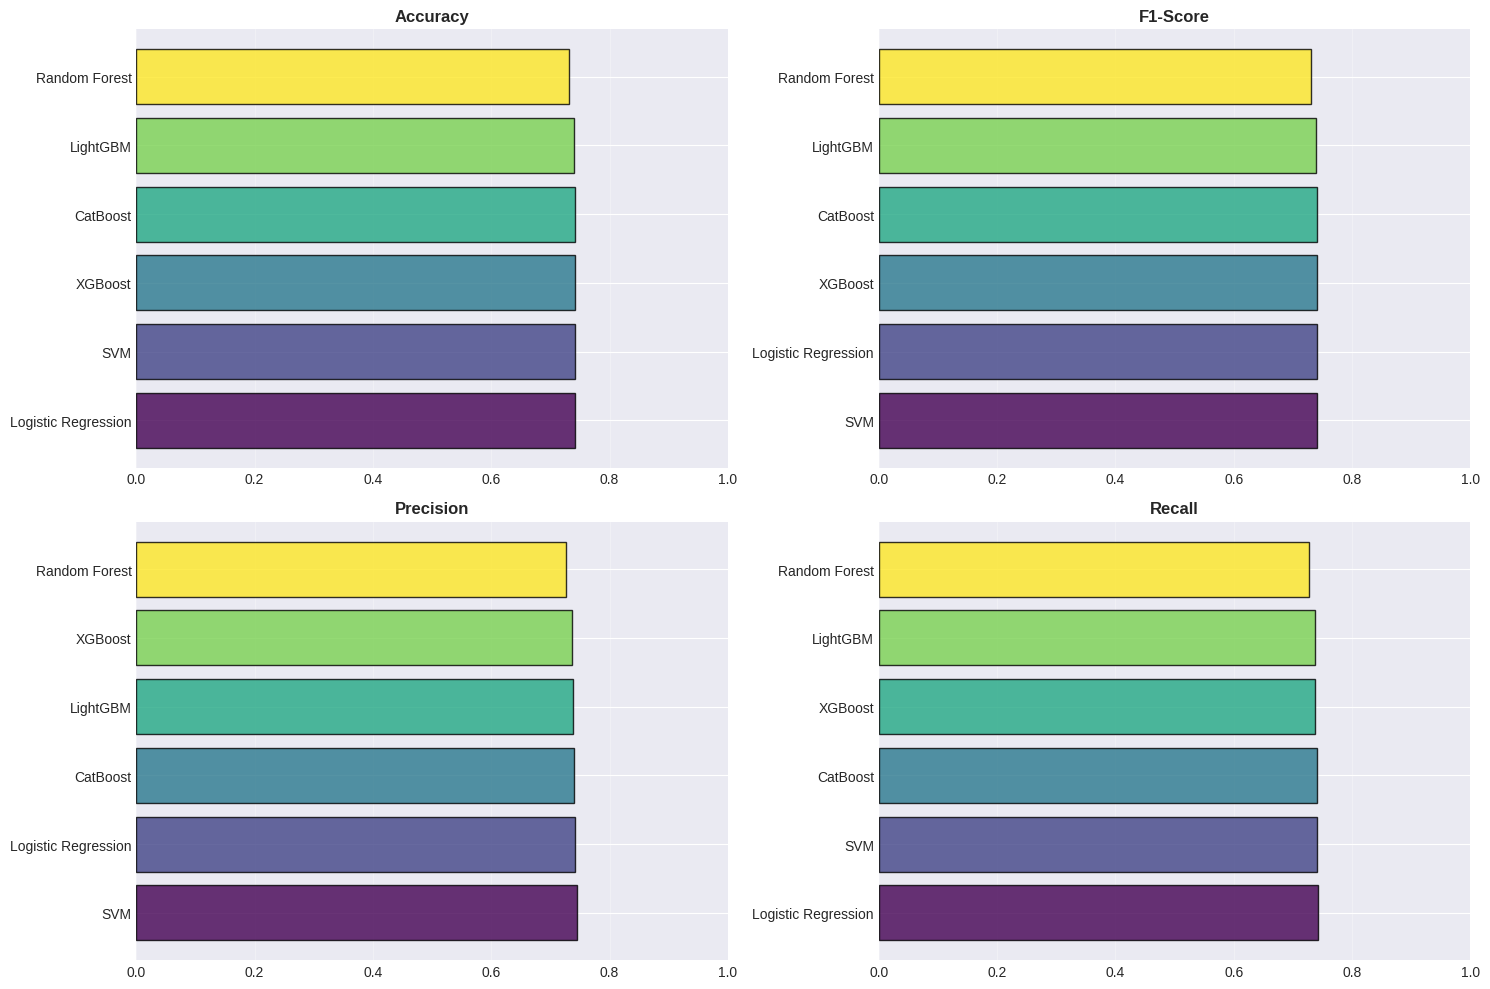

✓ Saved


In [24]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

for idx, metric in enumerate(['Accuracy', 'F1-Score', 'Precision', 'Recall']):
    ax = axes[idx//2, idx%2]
    if metric in comp_df.columns:
        data = comp_df[metric].sort_values(ascending=False)
        colors = plt.cm.viridis(np.linspace(0, 1, len(data)))
        ax.barh(data.index, data.values, color=colors, alpha=0.8, edgecolor='black')
        ax.set_title(f'{metric}', fontsize=12, fontweight='bold')
        ax.set_xlim([0, 1])
        ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('06_model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()
print('✓ Saved')

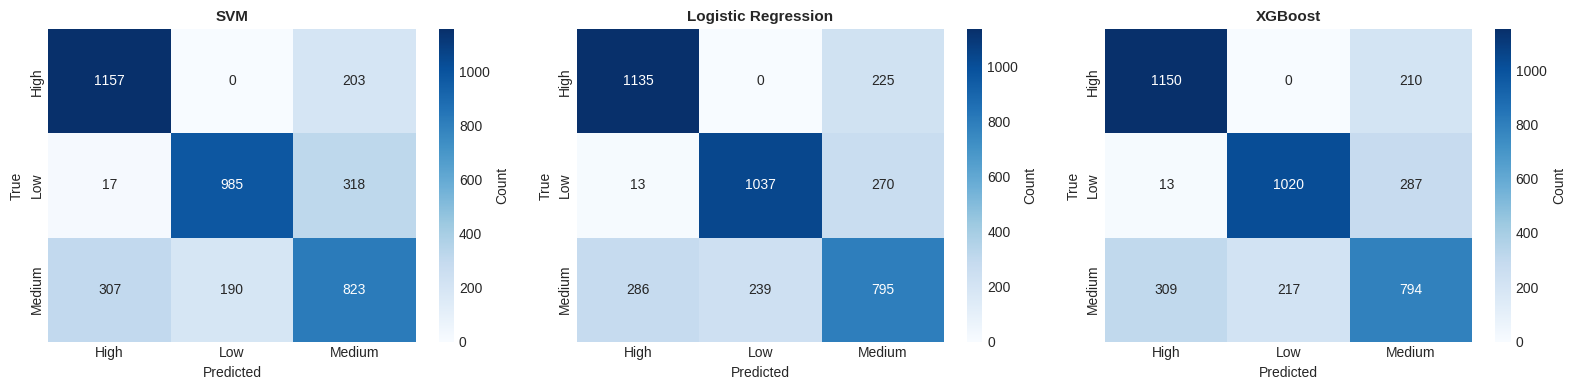

✓ Saved


In [26]:
top_3 = comp_df.index[:3].tolist()
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Get the original string labels from the LabelEncoder
original_labels = le.classes_

for idx, name in enumerate(top_3):
    mod = tuned_mods.get(name) or baseline_mods.get(name)
    y_pred = mod.predict(X_test_sc)

    # Use the encoded y_test for confusion matrix
    cm = confusion_matrix(y_test_encoded, y_pred)

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
               xticklabels=original_labels, yticklabels=original_labels,
               cbar_kws={'label': 'Count'})
    axes[idx].set_title(f'{name}', fontsize=11, fontweight='bold')
    axes[idx].set_ylabel('True')
    axes[idx].set_xlabel('Predicted')

plt.tight_layout()
plt.savefig('07_confusion_matrices.png', dpi=300, bbox_inches='tight')
plt.show()
print('✓ Saved')

## Phase 7: Feature Importance & Explainability

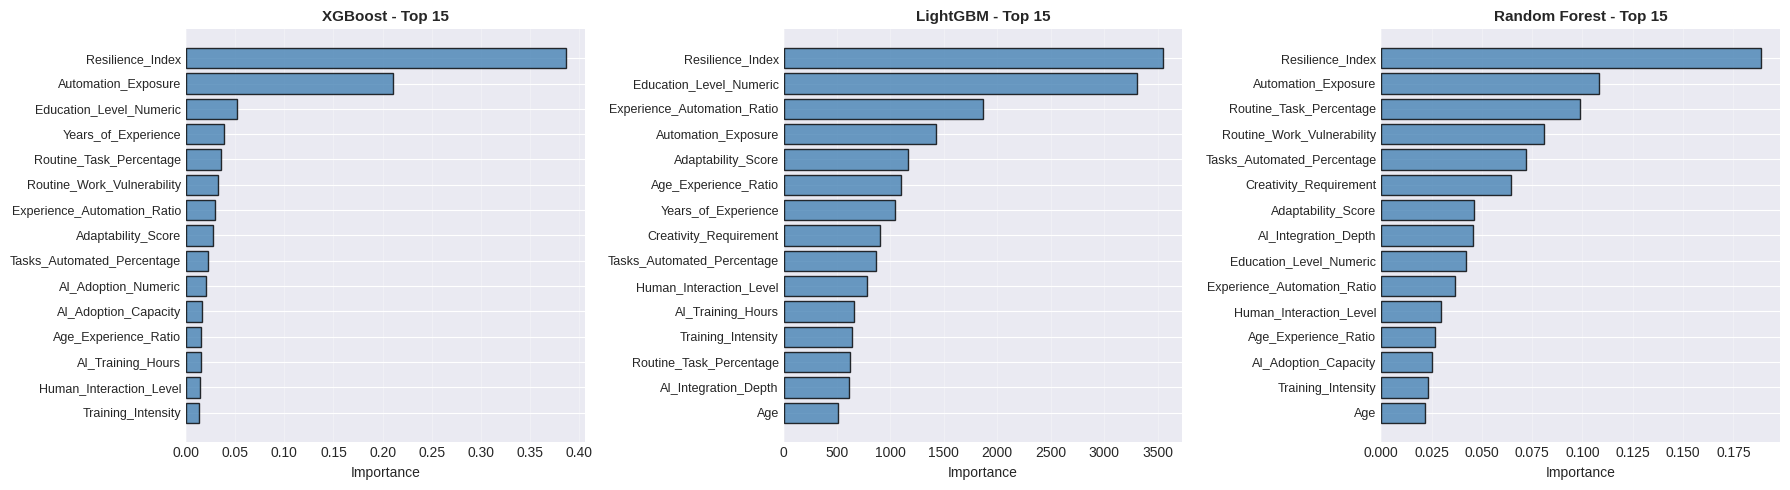

✓ Saved


In [27]:
tree_mods = ['XGBoost', 'LightGBM', 'Random Forest']
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, name in enumerate(tree_mods):
    mod = tuned_mods.get(name) or baseline_mods.get(name)
    if hasattr(mod, 'feature_importances_'):
        imp = mod.feature_importances_
        top_idx = np.argsort(imp)[-15:]

        axes[idx].barh(range(len(top_idx)), imp[top_idx], color='steelblue', alpha=0.8, edgecolor='black')
        axes[idx].set_yticks(range(len(top_idx)))
        axes[idx].set_yticklabels([X_train.columns[i] for i in top_idx], fontsize=9)
        axes[idx].set_title(f'{name} - Top 15', fontsize=11, fontweight='bold')
        axes[idx].set_xlabel('Importance')
        axes[idx].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('08_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()
print('✓ Saved')

In [28]:
best_name = comp_df.index[0]
best_mod = tuned_mods.get(best_name) or baseline_mods.get(best_name)

print(f'SHAP Analysis: {best_name}')
print('='*70)

X_sample = X_test_sc.iloc[:200]

try:
    if best_name in ['XGBoost', 'LightGBM']:
        explainer = shap.TreeExplainer(best_mod)
        shap_vals = explainer.shap_values(X_sample)

        if isinstance(shap_vals, list):
            shap_vals = shap_vals[0]

        plt.figure(figsize=(14, 8))
        shap.summary_plot(shap_vals, X_sample, plot_type='bar', show=False)
        plt.title(f'{best_name} - SHAP Feature Importance', fontsize=12, fontweight='bold')
        plt.tight_layout()
        plt.savefig('09_shap_summary.png', dpi=300, bbox_inches='tight')
        plt.show()
        print('✓ SHAP analysis complete')
    else:
        print(f'SHAP not available for {best_name}')
except Exception as e:
    print(f'SHAP skipped: {e}')

SHAP Analysis: SVM
SHAP not available for SVM


## Phase 8: Ensemble Methods & Final Results

In [29]:
print('ENSEMBLE METHODS')
print('='*70)

voting_ests = [
    (comp_df.index[0], tuned_mods.get(comp_df.index[0]) or baseline_mods.get(comp_df.index[0])),
    (comp_df.index[1], tuned_mods.get(comp_df.index[1]) or baseline_mods.get(comp_df.index[1])),
    (comp_df.index[2], tuned_mods.get(comp_df.index[2]) or baseline_mods.get(comp_df.index[2]))
]

voting_clf = VotingClassifier(estimators=voting_ests, voting='soft')
voting_clf.fit(X_train_bal, y_train_bal)

y_pred_vote = voting_clf.predict(X_test_sc)
f1_vote = f1_score(y_test, y_pred_vote, average='weighted')
acc_vote = accuracy_score(y_test, y_pred_vote)

print(f'\nVoting Ensemble:')
print(f'  Accuracy: {acc_vote:.4f}')
print(f'  F1-Score: {f1_vote:.4f}')
print('\n✓ Ensemble training complete')

ENSEMBLE METHODS

Voting Ensemble:
  Accuracy: 0.7410
  F1-Score: 0.7404

✓ Ensemble training complete


In [32]:
print('\nFINAL ANALYSIS SUMMARY')
print('='*80)
print(f'\nBest Individual Model: {best_name}')
print(f'  F1-Score: {comp_df.iloc[0]["F1-Score"]:.4f}')
print(f'  Accuracy: {comp_df.iloc[0]["Accuracy"]:.4f}')
print(f'\nVoting Ensemble F1: {f1_vote:.4f}')
print(f'\nDataset Info:')
print(f'  Samples: {len(df):,}')
print(f'  Features: {X.shape[1]}')
print(f'  Train: {X_train.shape[0]:,}, Test: {X_test.shape[0]:,}')

best_y_pred = best_mod.predict(X_test_sc)
print(f'\nClassification Report ({best_name}):')
# Use y_test_encoded for consistency and original_labels for readability
print(classification_report(y_test_encoded, best_y_pred, target_names=original_labels))


FINAL ANALYSIS SUMMARY

Best Individual Model: SVM
  F1-Score: 0.7414
  Accuracy: 0.7412

Voting Ensemble F1: 0.7404

Dataset Info:
  Samples: 20,000
  Features: 21
  Train: 16,000, Test: 4,000

Classification Report (SVM):
              precision    recall  f1-score   support

        High       0.78      0.85      0.81      1360
         Low       0.84      0.75      0.79      1320
      Medium       0.61      0.62      0.62      1320

    accuracy                           0.74      4000
   macro avg       0.74      0.74      0.74      4000
weighted avg       0.74      0.74      0.74      4000



In [33]:
comp_df.to_csv('model_comparison_results.csv')
print('✓ Saved: model_comparison_results.csv')

if hasattr(best_mod, 'feature_importances_'):
    feat_imp = pd.DataFrame({
        'Feature': X_train.columns,
        'Importance': best_mod.feature_importances_
    }).sort_values('Importance', ascending=False)

    feat_imp.to_csv('feature_importance.csv', index=False)
    print('✓ Saved: feature_importance.csv')

✓ Saved: model_comparison_results.csv


In [34]:
import zipfile
import os

files_to_zip = [f for f in os.listdir('.') if f.endswith(('.png', '.csv'))]
print(f'Creating archive with {len(files_to_zip)} files...')

with zipfile.ZipFile('AI_Impact_Layoff_Risk_Results.zip', 'w', zipfile.ZIP_DEFLATED) as zf:
    for f in files_to_zip:
        zf.write(f)
        print(f'  ✓ {f}')

print('\n✓ Archive: AI_Impact_Layoff_Risk_Results.zip')
print(f'  Size: {os.path.getsize("AI_Impact_Layoff_Risk_Results.zip") / (1024*1024):.2f} MB')

Creating archive with 10 files...
  ✓ model_comparison_results.csv
  ✓ 05_engineered_features.png
  ✓ ai-impact-jobs-layoff-risk-dataset.csv
  ✓ 04_correlation_matrix.png
  ✓ 03_categorical_distributions.png
  ✓ 02_numeric_distributions.png
  ✓ 06_model_comparison.png
  ✓ 07_confusion_matrices.png
  ✓ 01_target_distribution.png
  ✓ 08_feature_importance.png

✓ Archive: AI_Impact_Layoff_Risk_Results.zip
  Size: 2.48 MB


In [35]:
print('\n' + '='*80)
print('✓ ANALYSIS COMPLETE')
print('='*80)
print(f'\nCompleted: {pd.Timestamp.now()}')
print('\nAll outputs saved and ready for download!')
print('\nKey Findings:')
print(f'  • Best Model: {best_name}')
print(f'  • Test F1-Score: {comp_df.iloc[0]["F1-Score"]:.4f}')
print(f'  • Models Evaluated: {len(comp_df)}')
print(f'  • Features Used: {X.shape[1]} (including 12 engineered)')
print(f'  • Ensemble F1: {f1_vote:.4f}')


✓ ANALYSIS COMPLETE

Completed: 2026-06-09 03:59:29.160079

All outputs saved and ready for download!

Key Findings:
  • Best Model: SVM
  • Test F1-Score: 0.7414
  • Models Evaluated: 6
  • Features Used: 21 (including 12 engineered)
  • Ensemble F1: 0.7404
